**Minhas observações**

- "Notei que antes de partir para a pratica é ideal realizar anotações afim de entender qual problema precisa ser resolvido"
- Com as anotações em mãos fica mais facil saber quais tecnicas presisam ser usados para atacar o problema de maneira mais direta


TODO: Ler do 3.1.1, a 3.1.4 de maneira aprofundada até a proxima aula

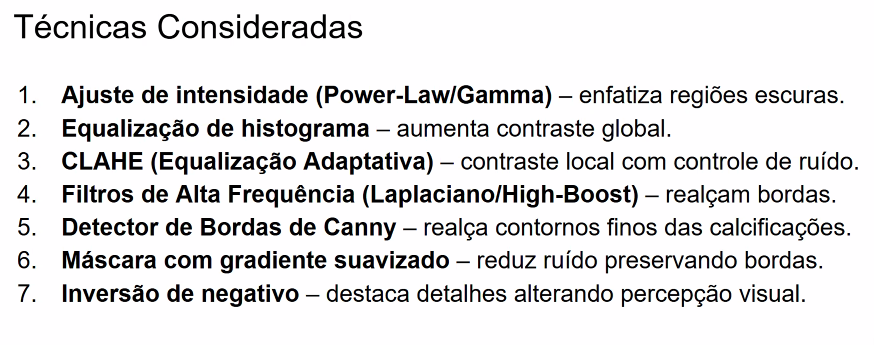

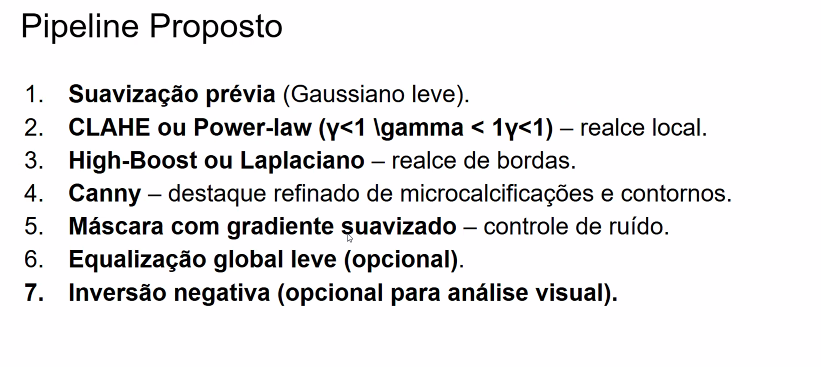

### Entendendo e descrevendo o problema


**Perguntas Oreentadoras**
1. Quais características da imagem original dificultam a visualização de calcificações?
    - **Baixo Contraste:** 
        - A diferença de intensidade entre as calcificações (que são tipicamente mais brilhantes) e o tecido mamário denso ao redor é mínima. 
        - Isso faz com que os pixels que representam a calcificação e o tecido vizinho tenham valores de cinza muito próximos, tornando-os visualmente indistinguíveis.
    - **Faixa Dinâmica Mal Distribuída:** 
        - A imagem pode conter regiões muito escuras (tecido adiposo) e muito claras (tecido glandular denso ou artefatos). 
        - Uma técnica de melhoria global (que aplica o mesmo ajuste a toda a imagem) pode saturar essas áreas (tornando-as completamente pretas ou brancas), eliminando detalhes cruciais, ao invés de revelá-los. 
        - As calcificações podem estar justamente nessas regiões de extremo.


2. Que tipo de ajustes poderia tornar as calcificações mais visíveis?
    - Precisamos de um ajuste que atue de forma **local**, e não global. 
    - O ideal é um **realce de contraste local adaptativo**. 
    - Em vez de aplicar uma única correção para toda a imagem, essa abordagem divide a imagem em pequenas regiões e ajusta o contraste de cada uma independentemente, com base na sua própria distribuição de intensidades. 
    - Isso permite "iluminar" detalhes em áreas escuras e "escurecer" detalhes em áreas claras, sem afetar o resto da imagem.


3. Por que algumas áreas da imagem podem esconder detalhes importantes?
    - Isso ocorre porque a sensibilidade do olho humano é limitada. 
    - Quando os pixels em uma determinada região possuem valores de intensidade muito próximos (por exemplo, uma calcificação com valor 150 e o tecido ao redor com valores entre 145 e 148), eles são percebidos como uma única cor ou tom de cinza. 
    - O objetivo do processamento é "esticar" essa faixa de valores (mapear 145 para 100, 148 para 130 e 150 para 200, por exemplo), tornando a diferença perceptível.

4. Em que outros contextos médicos uma técnica de melhoria de imagem seria útil?
Técnicas de realce de contraste local são vitais em diversas áreas da imagiologia médica:

Radiografias Ósseas: Para identificar fraturas finas ou fissuras.

Tomografias Computadorizadas (TC): Para melhorar a visualização de tumores ou anomalias em tecidos moles.

Ressonância Magnética (RM): Para realçar lesões no cérebro ou em outros órgãos.

Angiografia: Para melhorar a visibilidade de vasos sanguíneos e detectar obstruções.

Imagens de Retina: Para diagnosticar retinopatia diabética através da visualização de microaneurismas.

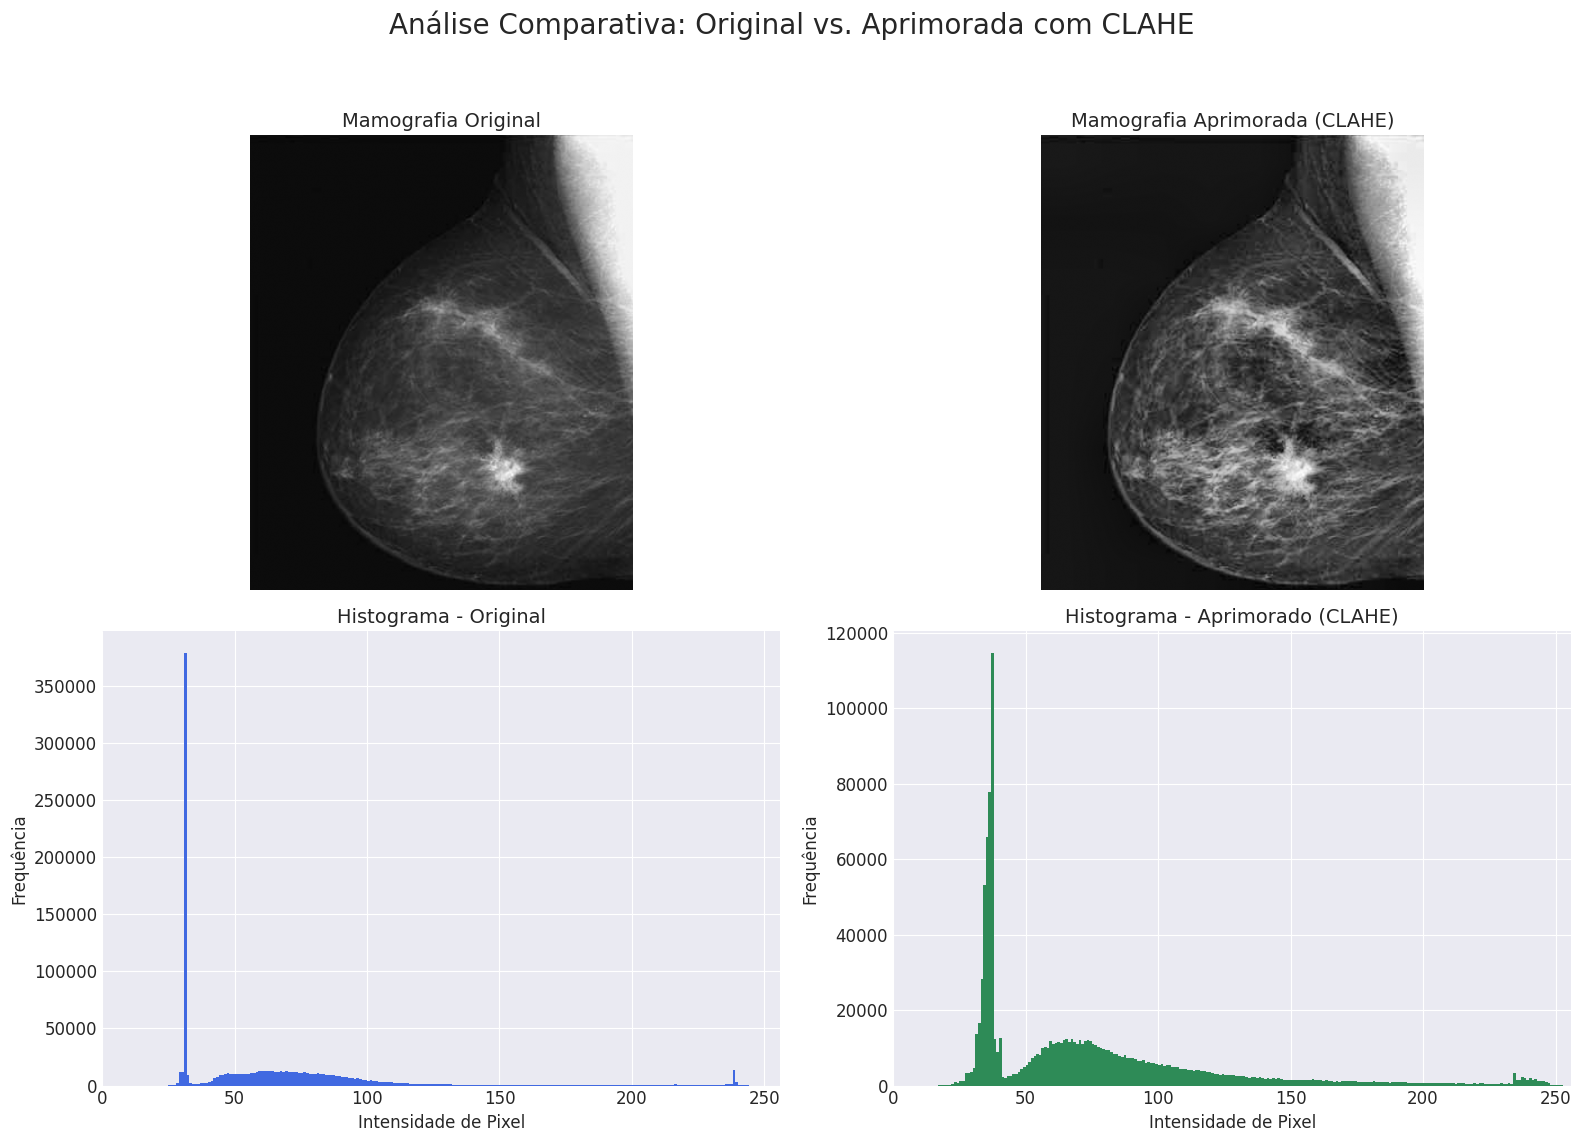

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Definindo um estilo visual mais agradável para os plots
plt.style.use('seaborn-v0_8-darkgrid')

def aprimorar_mamografia_com_clahe(caminho_imagem: str, clip_limit: float = 2.0, tile_grid_size: tuple = (8, 8)):
    """
    Aplica a técnica CLAHE para aprimorar a visibilidade em uma imagem de mamografia.

    Args:
        caminho_imagem (str): O caminho para o arquivo de imagem original.
        clip_limit (float): Limite para a amplificação de contraste. Valores mais altos
                            resultam em maior contraste. 2.0 é um bom ponto de partida.
        tile_grid_size (tuple): O tamanho da grade para a equalização adaptativa.

    Returns:
        tuple[np.ndarray, np.ndarray]: Uma tupla contendo a imagem original e a imagem aprimorada.
    """
    # Carrega a imagem em escala de cinza.
    # Imagens médicas como mamografias são inerentemente monocromáticas.
    imagem_original = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)
    if imagem_original is None:
        raise FileNotFoundError(f"Erro: Imagem não encontrada no caminho: {caminho_imagem}")

    # Cria o objeto CLAHE com os parâmetros definidos.
    # O clipLimit controla a amplificação de ruído.
    # O tileGridSize define as janelas locais para a análise.
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    # Aplica o CLAHE na imagem original.
    imagem_aprimorada = clahe.apply(imagem_original)

    return imagem_original, imagem_aprimorada

def visualizar_comparacao(original: np.ndarray, aprimorada: np.ndarray):
    """
    Exibe a imagem original e a aprimorada lado a lado, com seus respectivos histogramas.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Análise Comparativa: Original vs. Aprimorada com CLAHE', fontsize=20)

    # Imagem Original
    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title('Mamografia Original', fontsize=14)
    axes[0, 0].axis('off')

    # Histograma da Imagem Original
    axes[1, 0].hist(original.ravel(), bins=256, range=[0, 256], color='royalblue')
    axes[1, 0].set_title('Histograma - Original', fontsize=14)
    axes[1, 0].set_xlabel('Intensidade de Pixel')
    axes[1, 0].set_ylabel('Frequência')
    axes[1, 0].set_xlim([0, 256])

    # Imagem Aprimorada
    axes[0, 1].imshow(aprimorada, cmap='gray')
    axes[0, 1].set_title('Mamografia Aprimorada (CLAHE)', fontsize=14)
    axes[0, 1].axis('off')

    # Histograma da Imagem Aprimorada
    axes[1, 1].hist(aprimorada.ravel(), bins=256, range=[0, 256], color='seagreen')
    axes[1, 1].set_title('Histograma - Aprimorado (CLAHE)', fontsize=14)
    axes[1, 1].set_xlabel('Intensidade de Pixel')
    axes[1, 1].set_ylabel('Frequência')
    axes[1, 1].set_xlim([0, 256])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


if __name__ == '__main__':
    # --- Ponto de Execução ---
    # Para usar, substitua 'caminho/para/sua/mamografia.png' pelo caminho real do arquivo.
    # Como não temos a imagem, vamos criar uma imagem de exemplo que simula o problema.
    # def criar_mamografia_simulada(nome_arquivo='Case 1.png'):
    #     # Cria uma imagem com baixo contraste geral e algumas áreas claras/escuras
    #     img = np.full((512, 512), 128, dtype=np.uint8)
    #     # Adiciona uma região de tecido denso (um pouco mais clara)
    #     cv2.rectangle(img, (100, 100), (400, 400), 150, -1)
    #     # Adiciona "calcificações" sutis (pequenos pontos brilhantes)
    #     for _ in range(30):
    #         x, y = np.random.randint(150, 350, 2)
    #         cv2.circle(img, (x, y), 2, 165, -1) # Contraste muito baixo
    #     # Adiciona ruído gaussiano para simular a textura da imagem
    #     ruido = np.zeros(img.shape, np.uint8)
    #     cv2.randn(ruido, 0, 10)
    #     img = cv2.add(img, ruido)
    #     cv2.imwrite(nome_arquivo, img)
    #     return nome_arquivo

    # caminho_da_imagem = criar_mamografia_simulada()

    try:
        # Processa a imagem
        img_original, img_aprimorada = aprimorar_mamografia_com_clahe(caminho_da_imagem)
        # Visualiza os resultados
        visualizar_comparacao(img_original, img_aprimorada)
    except FileNotFoundError as e:
        print(e)

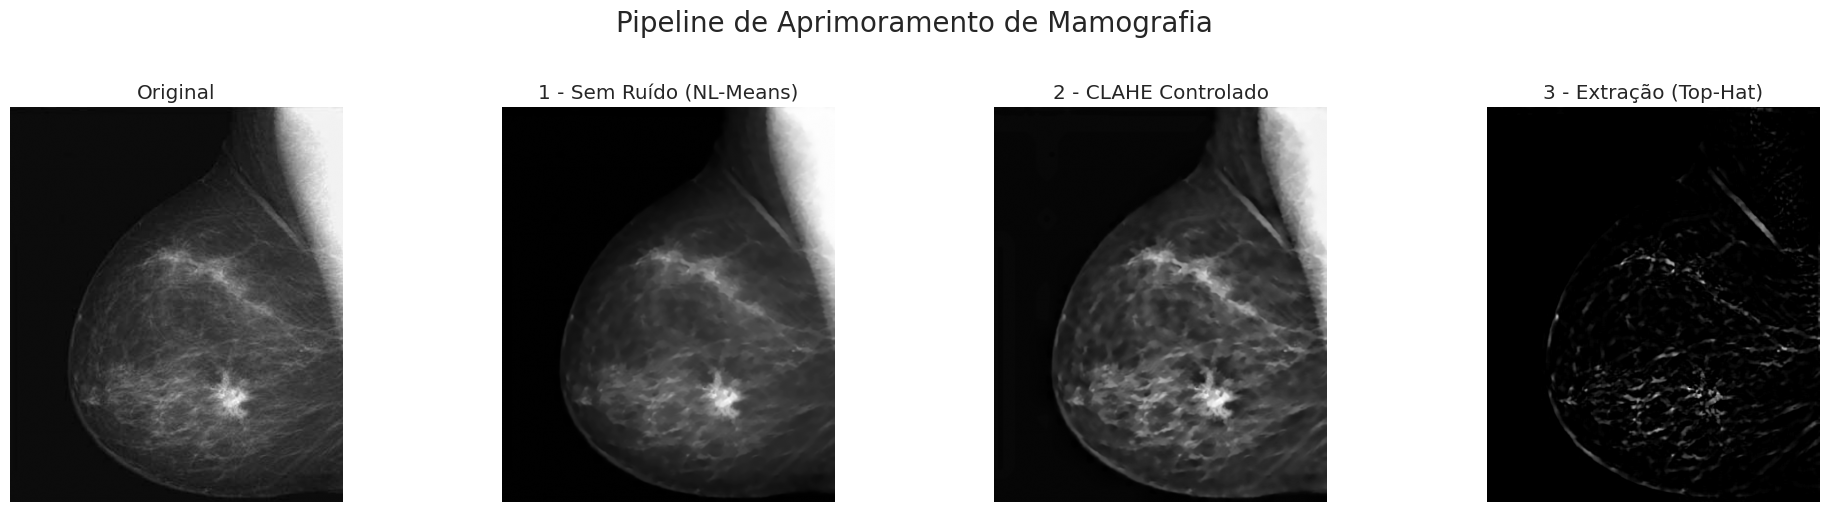

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Estilo visual profissional para os gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('figure', figsize=(18, 10))
plt.rc('font', size=12)

def carregar_imagem_cinza(caminho_imagem: str) -> np.ndarray:
    """Carrega uma imagem em escala de cinza, tratando erros."""
    imagem = cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE)
    if imagem is None:
        raise FileNotFoundError(f"Imagem não encontrada em: {caminho_imagem}")
    return imagem

def pipeline_aprimoramento_avancado(imagem_original: np.ndarray):
    """
    Executa um pipeline de processamento avançado para mamografias.

    1. Redução de ruído com Non-Local Means.
    2. Aplicação controlada de CLAHE na imagem sem ruído.
    3. Extração de características com a transformação Top-Hat.

    Retorna um dicionário com os resultados de cada etapa.
    """
    # --- Etapa 1: Redução de Ruído Inteligente ---
    # h: Parâmetro que regula a força do filtro. Valores maiores removem mais ruído.
    imagem_sem_ruido = cv2.fastNlMeansDenoising(imagem_original, h=10, templateWindowSize=7, searchWindowSize=21)

    # --- Etapa 2: CLAHE Controlado ---
    # Parâmetros menos agressivos para evitar artefatos.
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(16, 16))
    clahe_aplicado = clahe.apply(imagem_sem_ruido)

    # --- Etapa 3: Transformação Morfológica Top-Hat ---
    # O kernel define o tamanho do maior objeto que será removido.
    # Queremos remover tudo, exceto as pequenas calcificações.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    top_hat = cv2.morphologyEx(imagem_sem_ruido, cv2.MORPH_TOPHAT, kernel)
    
    return {
        "Original": imagem_original,
        "1 - Sem Ruído (NL-Means)": imagem_sem_ruido,
        "2 - CLAHE Controlado": clahe_aplicado,
        "3 - Extração (Top-Hat)": top_hat
    }

def visualizar_pipeline(resultados: dict):
    """Exibe os resultados do pipeline em um layout comparativo."""
    num_imagens = len(resultados)
    fig, axes = plt.subplots(1, num_imagens, figsize=(20, 5))
    fig.suptitle('Pipeline de Aprimoramento de Mamografia', fontsize=20, y=1.02)

    for ax, (titulo, imagem) in zip(axes, resultados.items()):
        ax.imshow(imagem, cmap='gray')
        ax.set_title(titulo)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Usaremos a mesma simulação, mas agora o pipeline deve lidar melhor com ela.
    # def criar_mamografia_simulada(nome_arquivo='Case 1.png'):
    #     img = np.full((512, 512), 128, dtype=np.uint8)
    #     cv2.rectangle(img, (100, 100), (400, 400), 150, -1)
    #     for _ in range(40):
    #         x, y = np.random.randint(150, 350, 2)
    #         cv2.circle(img, (x, y), 2, 165, -1)
    #     # Adicionando um ruído mais desafiador
    #     ruido = np.zeros(img.shape, np.uint8)
    #     cv2.randn(ruido, 0, 15)
    #     img = cv2.add(img, ruido)
    #     cv2.imwrite(nome_arquivo, img)
    #     return nome_arquivo

    # caminho_da_imagem = criar_mamografia_simulada()
    
    try:
        imagem_original = carregar_imagem_cinza(caminho_da_imagem)
        resultados_pipeline = pipeline_aprimoramento_avancado(imagem_original)
        visualizar_pipeline(resultados_pipeline)
    except FileNotFoundError as e:
        print(e)

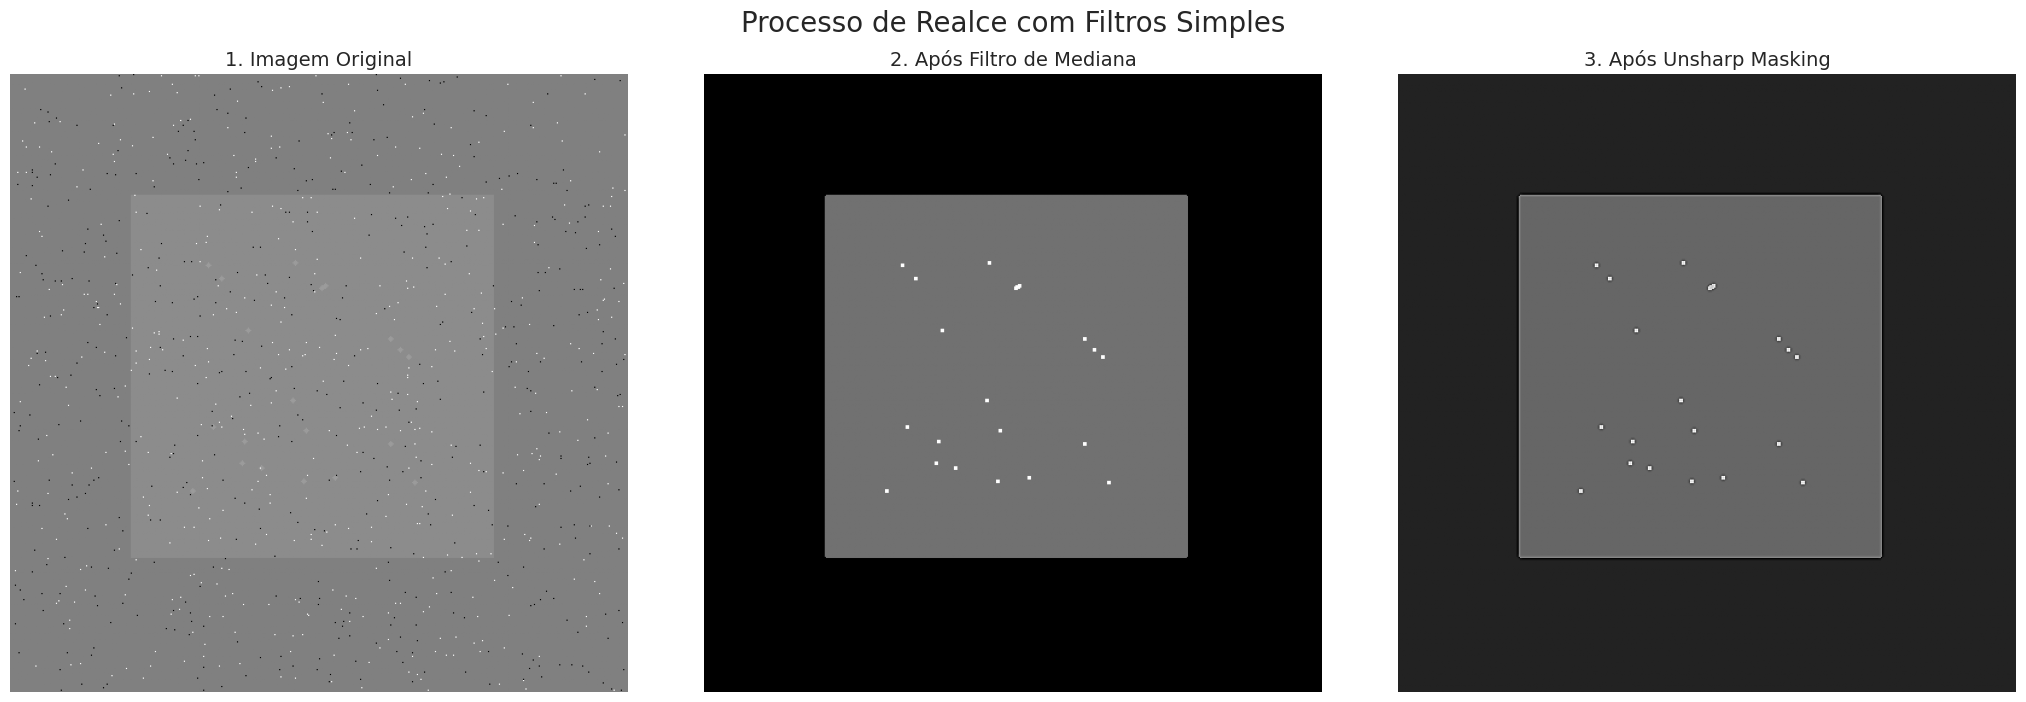

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Estilo visual para uma apresentação clara e profissional
plt.style.use('seaborn-v0_8-whitegrid')

def aplicar_filtro_mediana(imagem: np.ndarray, kernel_size: int = 3) -> np.ndarray:
    """
    Aplica um filtro de mediana para remover ruído "sal e pimenta".
    
    Args:
        imagem (np.ndarray): A imagem de entrada em escala de cinza.
        kernel_size (int): O tamanho da janela do filtro. Deve ser um ímpar positivo.
    
    Returns:
        np.ndarray: A imagem com ruído reduzido.
    """
    # Garante que o tamanho do kernel seja ímpar
    if kernel_size % 2 == 0:
        kernel_size += 1
    return cv2.medianBlur(imagem, kernel_size)

def aplicar_unsharp_mask(imagem: np.ndarray, sigma: float = 1.0, strength: float = 1.5) -> np.ndarray:
    """
    Aplica a técnica de Unsharp Masking para realçar a nitidez da imagem.
    
    Args:
        imagem (np.ndarray): A imagem de entrada em escala de cinza.
        sigma (float): O desvio padrão do blur Gaussiano (controla o "raio" do blur).
        strength (float): A força do realce (o "fator" na fórmula).
    
    Returns:
        np.ndarray: A imagem com nitidez realçada.
    """
    # 1. Criar a versão suavizada com um filtro Gaussiano
    imagem_suavizada = cv2.GaussianBlur(imagem, (0, 0), sigmaX=sigma)
    
    # 2. Calcular a máscara de detalhes (Original - Suavizada)
    # Usamos cv2.addWeighted para uma subtração controlada e evitar tipos de dados negativos
    mascara_detalhes = cv2.addWeighted(imagem, 1.0 + strength, imagem_suavizada, -strength, 0)
    
    return mascara_detalhes

def visualizar_processo_simples(original: np.ndarray, limpa: np.ndarray, realcada: np.ndarray):
    """Exibe o resultado do processo de filtragem simples."""
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.suptitle('Processo de Realce com Filtros Simples', fontsize=20, y=1.0)
    
    imagens = {
        "1. Imagem Original": original,
        "2. Após Filtro de Mediana": limpa,
        "3. Após Unsharp Masking": realcada
    }
    
    for ax, (titulo, imagem) in zip(axes, imagens.items()):
        ax.imshow(imagem, cmap='gray')
        ax.set_title(titulo, fontsize=14)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Simulação de uma mamografia com ruído e baixo contraste
    def criar_mamografia_simulada(nome_arquivo='Case 1.png'):
        img = np.full((512, 512), 128, dtype=np.uint8)
        cv2.rectangle(img, (100, 100), (400, 400), 140, -1) # Baixo contraste
        for _ in range(20):
            x, y = np.random.randint(150, 350, 2)
            cv2.circle(img, (x, y), 2, 155, -1) # Calcificações sutis
        # Adiciona ruído "sal e pimenta"
        for _ in range(1000):
            i, j = np.random.randint(0, 511, 2)
            img[i, j] = 255 if np.random.rand() > 0.5 else 0
        cv2.imwrite(nome_arquivo, img)
        return nome_arquivo

    caminho_da_imagem = criar_mamografia_simulada()
    
    # --- Pipeline de Execução ---
    try:
        # Carrega a imagem original
        imagem_original = cv2.imread(caminho_da_imagem, cv2.IMREAD_GRAYSCALE)
        
        # Etapa 1: Limpeza seletiva
        imagem_limpa = aplicar_filtro_mediana(imagem_original, kernel_size=3)
        
        # Etapa 2: Realce de detalhes
        imagem_realcada = aplicar_unsharp_mask(imagem_limpa, sigma=1.0, strength=1.5)
        
        # Visualização dos resultados
        visualizar_processo_simples(imagem_original, imagem_limpa, imagem_realcada)
        
    except FileNotFoundError as e:
        print(e)

In [16]:
caminho_da_imagem = 'Case 1.png'

imagem_original = cv2.imread(caminho_da_imagem, cv2.IMREAD_GRAYSCALE)

# Etapa 1: Limpeza seletiva
imagem_limpa = aplicar_filtro_mediana(imagem_original, kernel_size=3)

In [12]:
from libs import utils 

utils.imshow("", imagem_limpa)

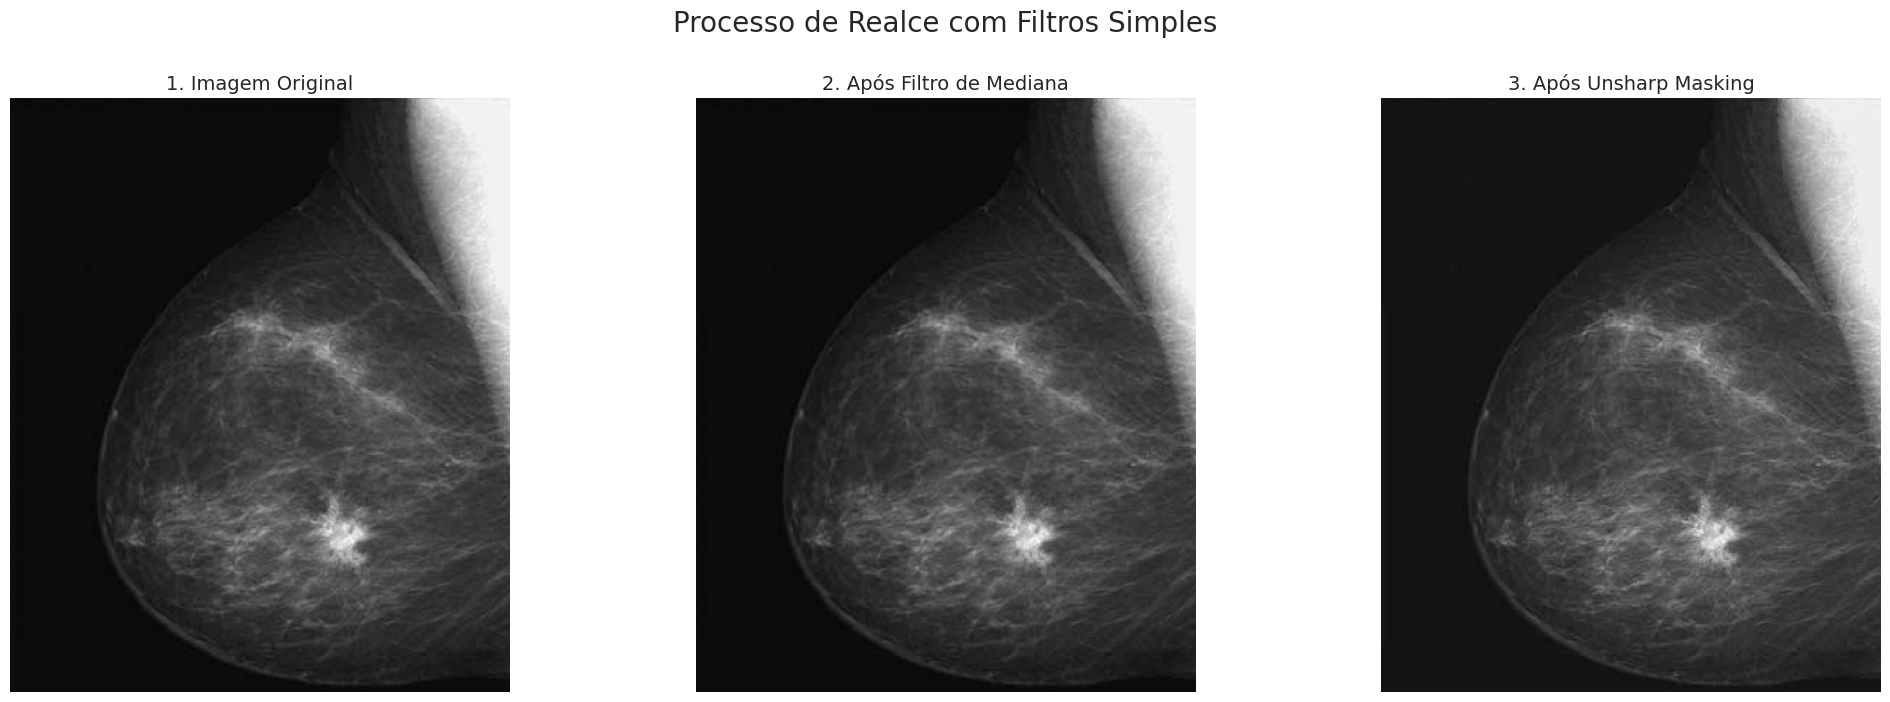

In [13]:
# Carrega a imagem original
imagem_original = cv2.imread(caminho_da_imagem, cv2.IMREAD_GRAYSCALE)

# Etapa 1: Limpeza seletiva
imagem_limpa = aplicar_filtro_mediana(imagem_original, kernel_size=3)

# Etapa 2: Realce de detalhes
imagem_realcada = aplicar_unsharp_mask(imagem_limpa, sigma=1.0, strength=1.5)

# Visualização dos resultados
visualizar_processo_simples(imagem_original, imagem_limpa, imagem_realcada)